In [24]:
import sys
sys.path.append("utils")

from bbox_utils import poly_to_bbox, split_bbox_horizontally, normalize_bbox
from preprocessing import is_numeric_token, is_keyword_token, find_stop_line, score_page, KEYWORDS, COMPILED_KEYWORDS, STOP_KEYWORDS
from ocr_utils import extract_text_lines, convert_file
from labeling import group_lines_by_row, detect_row_type, label_row, flatten_labels

## Step 1: OCR ##
The first step is to download paddleOCR and test it on some of the dataset. PaddleOCR is ran with *PaddlePaddle* as their deep learning model so it's important to download both libraries together

Source: https://github.com/PaddlePaddle/PaddleOCR

For CPU-only PaddlePaddle:
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

In [5]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False,)

c:\Users\alexr\anaconda3\envs\MLP\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
c:\Users\alexr\anaconda3\envs\MLP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
c:\Users\alexr\anaconda3\envs\MLP\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model file

### 1.1 Use OCR Prediction Model

In [7]:
result = ocr.predict(input="raw_pdfs/electric bills-part-4.pdf")

for page in result:
  page.save_to_img("pages")
  page.save_to_json("output")

## Step 2: Data Preprocessing ##
We've now saved our page into their folders pages and outputs, saving the images and json files respectively. <br><br>Utility companies send out bills with multiple pages of information. It would be a waste to train our model on all those pages where classification isn't needed. Similar to **Term Frequency-Inverse Document Frequency (TF-IDF)**, each page will be read to count through how many lines, words, and digits to determine which page is likely to have the itemized bill. We will move this file into its own folder to train and test on.

### 2.1 Necessary Import Statements

In [ ]:
import os, json, shutil
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

OCR_DIR = "output"
PAGES_DIR = "pages"
RAW_PDF = "raw_pdf"
TRAIN_IMG = "training_data/images"
TRAIN_ANN = "training_data/annotation_raw"
TRAIN_WRD = "training_data/annotation_words"
LOG_DIR = "logs"

### 2.2 Page Classification
Determine confidence scores of each line per page, and word density per page

In [ ]:
# Save score values per page
page_scores = []
confidence_scores = {}
# Loop through each page in the output
for fname in sorted(os.listdir(OCR_DIR)):
    path = os.path.join(OCR_DIR, fname)
    # Open file to read
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    # Retrieve confidence scores of all 3 pages together
    scores = data.get("rec_scores", [])
    if scores:
        confidence_scores[fname] = scores
    lines = extract_text_lines(data)
    stop_idx = find_stop_line(lines)
    lines = lines[:stop_idx]
    keyword_density, numeric_density = score_page(lines)

    print(f"{fname}: lines={len(lines)}, keyword_density={keyword_density:.4f}, numeric_density={numeric_density:.4f}")
    page_scores.append({
        "fname": fname,
        "keyword_density": keyword_density,
        "numeric_density": numeric_density,
    })

best_page = max(page_scores, key=lambda x: x["keyword_density"])


electric bills-part-4_0_res.json: lines=114, keyword_density=0.0171, numeric_density=0.1638
electric bills-part-4_1_res.json: lines=93, keyword_density=0.0940, numeric_density=0.2479
electric bills-part-4_2_res.json: lines=9, keyword_density=0.0000, numeric_density=0.2000


### 2.2.1 Plotting Page Classification Metrics

Below are some plots to show our metrics and results from paddleOCR. Checking our confidence scores is cricual to determining what values to use and whittle out the lines incorrectly recongized, while comparing density scores allows us to determine how we picked our best page

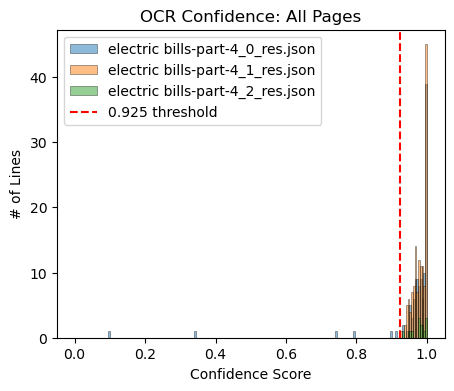

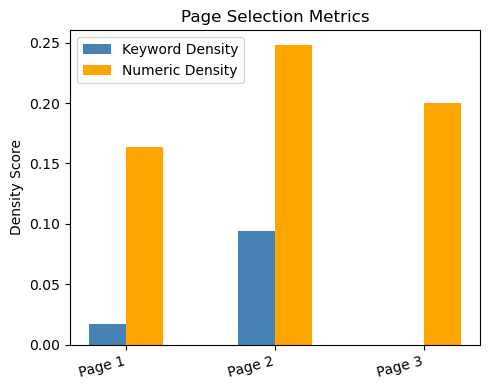

In [18]:
# Rule out specific lines with low confidence scores to avoid noisy details
plt.figure(figsize=(5, 4))
for fname, scores in confidence_scores.items():
  plt.hist(scores, bins=200, range=(0, 1), alpha = 0.5, edgecolor="black", label=fname, linewidth=0.5)
plt.title(f"OCR Confidence: All Pages")
plt.xlabel("Confidence Score")
plt.ylabel("# of Lines")
plt.axvline(x=0.925, color="red", linestyle="--", label="0.925 threshold")
plt.legend()
plt.show() 

# Retrieve metrics
page_names = [f"Page {i+1}" for i in range(len(page_scores))]
keyword_densities = [s["keyword_density"] for s in page_scores]
numeric_densities = [s["numeric_density"] for s in page_scores]
# Create x axis and bar width
x = np.arange(len(page_names))
width = 0.25
# Create bar plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width/2, keyword_densities, width, label="Keyword Density", color="steelblue")
ax.bar(x + width/2, numeric_densities, width, label="Numeric Density", color="orange")
ax.set_ylabel("Density Score")
ax.set_xticks(x)
ax.set_xticklabels(page_names, rotation=15, ha="right")
ax.set_title("Page Selection Metrics")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Page Selection
After determining which page is the one holding our bill. We will move these into the training dataset to train our model on.

In [ ]:
# Maintain base form of file to move
base = best_page['fname'].replace("_res.json","")
img_src = os.path.join(PAGES_DIR, base+"_ocr_res_img.png")
ann_src = os.path.join(OCR_DIR, best_page['fname'])

if best_page:
  # Move JSON to annotations
  ann_dst = os.path.join(TRAIN_ANN, best_page['fname'])
  shutil.copy2(ann_src, ann_dst)

  # Move image to training images
  if os.path.exists(img_src):
    img_dst = os.path.join(TRAIN_IMG, base + ".png")
    shutil.copy2(img_src, img_dst)

### 2.4 Prep JSON File for Labeling
Now it's crucial we build our labels for LayoutLM accordingly

In [ ]:

img_path = os.path.join(TRAIN_IMG, base + ".png")
with Image.open(img_path) as img:
    page_width, page_height = img.size
# Use object oriented Path instead of os.join
input_file = Path(TRAIN_ANN) / best_page['fname']
# Convert to LayoutLM ready format
entries = convert_file(input_file)
rows = group_lines_by_row(entries)
labeled_rows = [label_row(row) for row in rows]
page_entry = flatten_labels(
    page_id = base,
    image_path = (Path(TRAIN_IMG) / (base + ".png")).as_posix(),
    labeled_rows= labeled_rows,
    page_width= page_width,
    page_height= page_height
)

out_path = Path(TRAIN_WRD) / (base + ".json" )
with out_path.open("w", encoding="utf-8") as fh:
    fh.write(json.dumps(page_entry, ensure_ascii=False, indent=2) + "\n")

# Print token/label pairs for inspection
print(f"\n{'TOKEN':<20} {'LABEL'}")
print("-" * 35)
for token, label in zip(page_entry["tokens"], page_entry["labels"]):
    if label != "O":  # only print non-O labels to reduce noise
        print(f"{token:<20} {label}")


TOKEN                LABEL
-----------------------------------
32                   B-KWH_USAGE
58200                B-KWH_COST
$2,841.38            B-TOTAL_COST
3,271.83             B-KWH_COST
207.0                B-KW_USAGE
527.22               B-KW_COST
2400                 B-KWH_USAGE
223.19               B-KWH_COST


### NOT NEEDED: Intermediate Step ###

Currently my labeling scheme can only get me so far. To ensure correct training is done, we can use label-studio to finish labeling our pipeline

In [ ]:
LABEL_STD = "training_data/label_studio"
from urllib.parse import quote

def convert_to_label_studio(jsonl_path, output_path, image_root):
    with open(jsonl_path, "r") as f:
        page = json.load(f)

    
    image_filename = page['id'] + ".png"
    encoded_filename = quote(image_filename)
    tasks = []
    for token, bbox, label in zip(page["tokens"], page["bboxes"], page["labels"]):
        x1, y1, x2, y2 = bbox
        tasks.append({
            "data": {
                "image": f"/data/local-files/?d=training_data/images/{encoded_filename}",
                "text": token,
            },
            "predictions": [{
                "result": [{
                    "type": "rectanglelabels",
                    "from_name": "label",
                    "to_name": "image",
                    "value": {
                        "x":      x1 / 10,   # Label Studio uses 0-100
                        "y":      y1 / 10,
                        "width":  (x2 - x1) / 10,
                        "height": (y2 - y1) / 10,
                        "rectanglelabels": [label]
                    }
                }]
            }]
        })
    
    with open(output_path, "w") as f:
        json.dump(tasks, f, indent=2)
    
    print(f"Exported {len(tasks)} tokens to {output_path}")

convert_to_label_studio(
    jsonl_path  = Path(TRAIN_WRD) / (base + ".json"),
    output_path = Path(LABEL_STD) / (base + "label_studio_import.json"),
    image_root  = TRAIN_IMG
)
print(os.getcwd())

## Step 3: LayoutLMv3 ##
Now comes our model we are going to use for transfer learning. LayoutLM extends the traditional trasnformer model by integrating layout information into the input embeddings designed for document AI tasks that can model texts, images and layout together. It will be the backbone of our project. Now that we have filtered our data into each respective folder, let's pass it into our model to fine-tune it.

In [ ]:
from transformers import AutoProcessor, AutoModel

processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)
model = AutoModel.from_pretrained("microsoft/layoutlmc3-base")